# **Electricity Load Forecasting Using LSTM/GRU/CN**

In [4]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import copy

# Training will be significantly faster if GPU is available.
# In Colab: Runtime -> Change runtime type -> Hardware accelerator -> GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


# Load Data

In [5]:
# Works both locally and on Colab — falls back to a local data.xlsx if google.colab is unavailable.
try:
    from google.colab import files
    uploaded = files.upload()
except ModuleNotFoundError:
    pass  # local run: data.xlsx is expected to sit next to this notebook

xls = pd.ExcelFile('data.xlsx')
print('Sheets:', xls.sheet_names)


Sheets: ['load_history', 'load_benchmark', 'load_solution', 'temperature_history', 'temperature_solution']


In [6]:
# Save all sheets as pandas dataframes
load_history        = pd.read_excel(xls, sheet_name='load_history')
load_benchmark      = pd.read_excel(xls, sheet_name='load_benchmark')
load_solution       = pd.read_excel(xls, sheet_name='load_solution')
temperature_history = pd.read_excel(xls, sheet_name='temperature_history')
temperature_solution = pd.read_excel(xls, sheet_name='temperature_solution')

# Per Maneesha's brief, Step 2: data should already be Zone 2 only. data.xlsx
# was pre-extracted upstream — no zone_id column should remain.
for name, df in [('load_history', load_history), ('load_benchmark', load_benchmark),
                 ('load_solution', load_solution), ('temperature_history', temperature_history),
                 ('temperature_solution', temperature_solution)]:
    assert 'zone_id' not in df.columns, f'{name} still has zone_id column — extract Zone 2 first'
print('Zone-2 assertion OK. Columns of load_history:', list(load_history.columns[:6]), '...')


Zone-2 assertion OK. Columns of load_history: ['year', 'month', 'day', 'h1', 'h2', 'h3'] ...


# Feature Engineering

First, set all features that already exist as actual features

In [7]:
# LOAD HISTORY
#     this is the load for the train/val period
# Convert hour columns to individual readings
df_load_history = load_history.melt(id_vars=['year','month','day'], var_name='hour', value_name='load')
df_load_history['hour'] = df_load_history['hour'].str.replace('h','').astype(int)-1
# Get the datetime
df_load_history['datetime'] = pd.to_datetime(df_load_history[['year', 'month', 'day']]) + pd.to_timedelta(df_load_history['hour'], unit='h')
# Sort by datetime
df_load_history = df_load_history.sort_values('datetime')

# LOAD BENCHMARK
#     this is the benchmark solution that should be attempted to be beaten
# Convert hour columns to individual readings
df_load_benchmark = load_benchmark.melt(id_vars=['year','month','day'], var_name='hour', value_name='load')
df_load_benchmark['hour'] = df_load_benchmark['hour'].str.replace('h','').astype(int)-1
# Get the datetime
df_load_benchmark['datetime'] = pd.to_datetime(df_load_benchmark[['year', 'month', 'day']]) + pd.to_timedelta(df_load_benchmark['hour'], unit='h')
# Sort by datetime
df_load_benchmark = df_load_benchmark.sort_values('datetime')

# LOAD SOLUTION
#     this is the load for the test period
# Convert hour columns to individual readings
df_load_solution = load_solution.melt(id_vars=['year','month','day'], var_name='hour', value_name='load')
df_load_solution['hour'] = df_load_solution['hour'].str.replace('h','').astype(int)-1
df_load_solution['datetime'] = pd.to_datetime(df_load_solution[['year', 'month', 'day']]) + pd.to_timedelta(df_load_solution['hour'], unit='h')
# Sort by datetime
df_load_solution = df_load_solution.sort_values('datetime')

# TEMPERATURE HISTORY
#     this is the temperature for the train/val period
# Convert hour columns to individual readings
df_temperature_history = temperature_history.melt(id_vars=['year','month','day'], var_name='hour', value_name='temperature')
df_temperature_history['hour'] = df_temperature_history['hour'].str.replace('h','').astype(int)-1
# Get the datetime
df_temperature_history['datetime'] = pd.to_datetime(df_temperature_history[['year', 'month', 'day']]) + pd.to_timedelta(df_temperature_history['hour'], unit='h')
# Sort by datetime
df_temperature_history = df_temperature_history.sort_values('datetime')
# Save only necessary columns
df_temperature_history = df_temperature_history[['datetime', 'temperature']]

# TEMPERATURE SOLUTION
#     this is the temperature for the test period
# Convert hour columns to individual readings
df_temperature_solution = temperature_solution
df_temperature_solution['hour'] = df_temperature_solution['hour'].astype(int)-1
df_temperature_solution['datetime'] = pd.to_datetime(df_temperature_solution[['year', 'month', 'day']]) + pd.to_timedelta(df_temperature_solution['hour'], unit='h')
# Get the datetime
df_temperature_solution = df_temperature_solution.sort_values('datetime')
# Sort by datetime
df_temperature_solution['temperature'] = df_temperature_solution['T0_p1']
# Save only necessary columns
df_temperature_solution = df_temperature_solution[['datetime', 'temperature']]


# Set datetime as the index for all
df_load_history = df_load_history.set_index('datetime')
df_load_benchmark = df_load_benchmark.set_index('datetime')
df_load_solution = df_load_solution.set_index('datetime')
df_temperature_history = df_temperature_history.set_index('datetime')
df_temperature_solution = df_temperature_solution.set_index('datetime')

**Possible Additional Features:**
*   Day of Week
*   Weekend Flag (behavioural changes)
*   Month (seasonal demand)
*   Holiday Flag (behavioural changes/load anomalies)
*   Temperature/Weather (behavioural changes)


Also a good option to wrap features using sin/cos wrapping as this helps CNN's work better

In [8]:
# Convert to sin/cos wrapping (hour)
df_load_history['hour_sin'] = np.sin(2*np.pi*df_load_history.index.hour/24)
df_load_history['hour_cos'] = np.cos(2*np.pi*df_load_history.index.hour/24)
df_load_solution['hour_sin'] = np.sin(2*np.pi*df_load_solution.index.hour/24)
df_load_solution['hour_cos'] = np.cos(2*np.pi*df_load_solution.index.hour/24)

# Cyclical month encoding (replaces raw int month so Jan and Dec are adjacent, and the
# feature lives in [-1, 1] like hour_sin/cos — no scale mismatch into the CNN).
df_load_history['month_sin'] = np.sin(2*np.pi*df_load_history.index.month/12)
df_load_history['month_cos'] = np.cos(2*np.pi*df_load_history.index.month/12)
df_load_solution['month_sin'] = np.sin(2*np.pi*df_load_solution.index.month/12)
df_load_solution['month_cos'] = np.cos(2*np.pi*df_load_solution.index.month/12)

# Add day of week flag to train/val period
df_load_history['dayofweek'] = df_load_history.index.dayofweek
# Add weekend flag to train/val period
df_load_history['is_weekend'] = df_load_history['dayofweek'].apply(lambda x: 1 if x in [5, 6] else 0)

# Add day of week flag to test period
df_load_solution['dayofweek'] = df_load_solution.index.dayofweek
# Add weekend flag to test period
df_load_solution['is_weekend'] = df_load_solution['dayofweek'].apply(lambda x: 1 if x in [5, 6] else 0)

# Create holiday list
holidays = [
    '2006-01-02','2006-01-16','2006-02-20','2006-05-29','2006-07-04',
    '2006-09-04','2006-10-09','2006-11-10','2006-11-23','2006-12-25',
    '2007-01-01','2007-01-15','2007-02-19','2007-05-28','2007-07-04',
    '2007-09-03','2007-10-08','2007-11-12','2007-11-22','2007-12-25',
    '2008-01-01','2008-01-21','2008-02-18','2008-05-26','2008-07-04']
holidays = pd.to_datetime(holidays)
df_load_history['is_holiday'] = df_load_history.index.normalize().isin(holidays).astype(int)
df_load_solution['is_holiday'] = df_load_solution.index.normalize().isin(holidays).astype(int)

FEATURE_COLS = ['month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'load']
df_load_history = df_load_history[FEATURE_COLS]
df_load_solution = df_load_solution[FEATURE_COLS]

# Add temperature data to load set
df_history = df_load_history.join(df_temperature_history)
df_solution = df_load_solution.join(df_temperature_solution)

# Reorder with target at the end (visual aid)
ORDERED = ['month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'temperature', 'load']
df_history = df_history[ORDERED]
df_solution = df_solution[ORDERED]


# Preprocessing

1. **Missing values & outliers.** The melt step produces NaN load rows for 2008-07-01..2008-07-07 (whole test week — held in `load_solution`) and a partial NaN block for 2008-06-30 hours 7–24.

   Slice `df_history` to the train+val span (2006-11-29 .. 2008-06-29 inclusive) *before* outlier cleaning, so the centered rolling window cannot see the test-week NaN tail or pull any boundary information across.

   Outliers are then replaced with a rolling median (load: window=168h, 3σ; temperature: window=24h, 3σ).


In [9]:
# --- Missing value report (full melted span, before any slicing) ---
print('Missing values in df_history (full melted span):')
print(df_history.isna().sum())

# Restrict to the train+val span BEFORE outlier cleaning, so the centered rolling
# window cannot see test-week NaNs or any post-2008-06-29 values. Test data is
# kept separate in df_solution and is not touched here.
trainval = df_history.loc['2006-11-29':'2008-06-29'].copy()

def replace_outliers_with_rolling_median(series, window=24, threshold=3):
    rolling_mean   = series.rolling(window=window, center=True).mean()
    rolling_std    = series.rolling(window=window, center=True).std()
    rolling_median = series.rolling(window=window, center=True).median()
    upper = rolling_mean + threshold * rolling_std
    lower = rolling_mean - threshold * rolling_std
    outlier_mask = ((series > upper) | (series < lower))
    cleaned = series.copy()
    cleaned[outlier_mask] = rolling_median[outlier_mask]
    return cleaned, outlier_mask

load_cleaned, load_outliers = replace_outliers_with_rolling_median(trainval['load'], window=168, threshold=3)
temperature_cleaned, temp_outliers = replace_outliers_with_rolling_median(trainval['temperature'], window=24, threshold=3)

print('\nLoad outliers replaced:', int(load_outliers.sum()))
print('Temperature outliers replaced:', int(temp_outliers.sum()))

trainval['load']        = load_cleaned
trainval['temperature'] = temperature_cleaned

# Drop any residual NaN rows (none expected in this span, defensive).
trainval = trainval.dropna()


Missing values in df_history (full melted span):
month_sin        0
month_cos        0
hour_sin         0
hour_cos         0
is_weekend       0
is_holiday       0
temperature    186
load           186
dtype: int64

Load outliers replaced: 1
Temperature outliers replaced: 0


2. **Train / Val / Test split.** Time-series data, preserve sequential order. Test is fixed by the brief; train and val sizes are chosen to give the val window a representative slice of late-spring seasonality.

   - **Train period:** 2006-11-29 (first hour) → 2008-04-30 (last hour)
   - **Validation period:** 2008-05-01 (first hour) → 2008-06-29 (last full day; 2008-06-30 only has hours 1–6 in the source and is dropped)
   - **Test period:** 2008-07-01 (first hour) → 2008-07-07 (last hour) — `df_solution`


In [10]:
train = trainval.loc['2006-11-29':'2008-04-30'].copy()
val   = trainval.loc['2008-05-01':'2008-06-29'].copy()
test  = df_solution.copy()

# Sanity check — must be NaN-free before training
assert train.isna().sum().sum() == 0, f'NaNs in train: {train.isna().sum().to_dict()}'
assert val.isna().sum().sum()   == 0, f'NaNs in val:   {val.isna().sum().to_dict()}'
assert test.isna().sum().sum()  == 0, f'NaNs in test:  {test.isna().sum().to_dict()}'
print(f'Train: {train.index.min()} .. {train.index.max()}  ({len(train)} rows)')
print(f'Val:   {val.index.min()} .. {val.index.max()}  ({len(val)} rows)')
print(f'Test:  {test.index.min()} .. {test.index.max()}  ({len(test)} rows)')


Train: 2006-11-29 00:00:00 .. 2008-04-30 23:00:00  (12456 rows)
Val:   2008-05-01 00:00:00 .. 2008-06-29 23:00:00  (1440 rows)
Test:  2008-07-01 00:00:00 .. 2008-07-07 23:00:00  (168 rows)


# Scaling



3. **Normalise:** Fit the scalar to load based on training data only. Normalise using mean/std and apply the same transformation to val/test.
Same for temperature.

In [11]:
# Initialise scalers for load and temperature data
load_scaler = StandardScaler()
temp_scaler = StandardScaler()
# Fit the scalers to the train period
train['load'] = load_scaler.fit_transform(train[['load']])
train['temperature'] = temp_scaler.fit_transform(train[['temperature']])
# Apply the scaler to the val and test periods
val['load'] = load_scaler.transform(val[['load']])
val['temperature'] = temp_scaler.transform(val[['temperature']])
test['load'] = load_scaler.transform(test[['load']])
test['temperature'] = temp_scaler.transform(test[['temperature']])

In [12]:
print('All Features and Target')
print(train.columns.tolist())


All Features and Target
['month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday', 'temperature', 'load']


# Deep Learning Architecture

**Leakage discipline.** This is a **multi-step direct** forecast:

- Input window = past 168 hours (real load + real exogenous features) ∥ next 24 hours (exogenous features only; future load is masked to 0).
- Output = 24 load values in a single forward pass (`nn.Linear(64, horizon=24)`).
- The model never autoregressively consumes its own previous-hour prediction, and it never sees the actual future load. The only future information used is *exogenous* (month / hour / weekend / holiday flag / temperature) — which the brief explicitly allows.
- Temperature for the test week is taken from `temperature_solution` (`T0_p1` column) per the brief, treated as a known external regressor.

# 1D CNN Model For 24 Hour Electricity Load Forecasting

X_train: (12265, 8, 192)   y_train: (12265, 24)
X_val:   (1417, 8, 192)   y_val:   (1417, 24)
Epoch 001 | Train Loss: 0.63758 | Val Loss: 0.69011
Epoch 002 | Train Loss: 0.52926 | Val Loss: 0.63001
Epoch 003 | Train Loss: 0.48579 | Val Loss: 0.62304
Epoch 004 | Train Loss: 0.37441 | Val Loss: 0.14792
Epoch 005 | Train Loss: 0.23693 | Val Loss: 0.12365
Epoch 006 | Train Loss: 0.20289 | Val Loss: 0.13682
Epoch 007 | Train Loss: 0.17352 | Val Loss: 0.08800
Epoch 008 | Train Loss: 0.15153 | Val Loss: 0.09156
Epoch 009 | Train Loss: 0.14085 | Val Loss: 0.10608
Epoch 010 | Train Loss: 0.13470 | Val Loss: 0.10144
Epoch 011 | Train Loss: 0.12709 | Val Loss: 0.09346
Epoch 012 | Train Loss: 0.12540 | Val Loss: 0.09150
Epoch 013 | Train Loss: 0.11911 | Val Loss: 0.08312
Epoch 014 | Train Loss: 0.11624 | Val Loss: 0.07902
Epoch 015 | Train Loss: 0.11489 | Val Loss: 0.08491
Epoch 016 | Train Loss: 0.11252 | Val Loss: 0.09510
Epoch 017 | Train Loss: 0.10927 | Val Loss: 0.07458
Epoch 018 | Train Loss

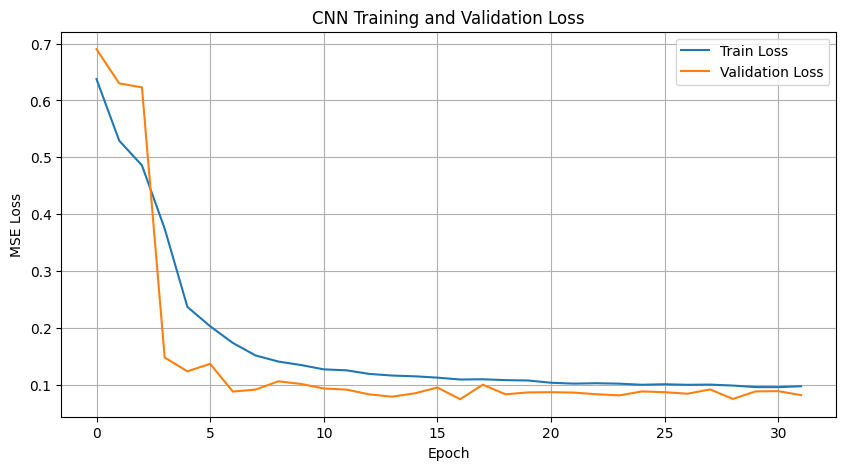

In [13]:
import copy
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------
# Settings
# -----------------------------
LOOKBACK = 168     # Past 7 days
HORIZON = 24       # Forecast next 24 hours in one go (multi-step direct)
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 15
LR = 0.001

feature_cols = ['month_sin', 'month_cos', 'hour_sin', 'hour_cos',
                'is_weekend', 'is_holiday', 'temperature', 'load']
target_col = 'load'

# -----------------------------
# Build sliding windows.
# Past 168h: real features (incl. real load).
# Future 24h: real exogenous features only; future load is REPLACED WITH 0
#            so the model cannot see the answer it is trying to predict.
# Target:    next 24 hours of load (scaled).
# This is a one-shot 24-point output (no autoregressive feedback) — i.e. no leakage
# of the actual previous-hour load into the next-hour prediction.
# -----------------------------
def make_windows(df, lookback=LOOKBACK, horizon=HORIZON):
    X, y = [], []
    for start in range(lookback, len(df) - horizon + 1):
        past_window = df.iloc[start-lookback:start][feature_cols].copy()
        future_window = df.iloc[start:start+horizon][feature_cols].copy()
        future_window['load'] = 0.0  # mask: no future-load leakage
        input_window = pd.concat([past_window, future_window], axis=0)
        output_window = df.iloc[start:start+horizon][target_col].values
        X.append(input_window.values)
        y.append(output_window)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train)

# Validation needs the prior 168 hours of context that lives in train
val_context = pd.concat([train.tail(LOOKBACK), val])
X_val, y_val = make_windows(val_context)

# CNN expects shape: (batch, channels=features, sequence_length)
X_train = np.transpose(X_train, (0, 2, 1))
X_val   = np.transpose(X_val, (0, 2, 1))

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
                          batch_size=BATCH_SIZE, shuffle=False)

print("X_train:", X_train.shape, "  y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "  y_val:  ", y_val.shape)

# -----------------------------
# 1D CNN — multi-step direct: outputs all 24 hours in one forward pass
# -----------------------------
class LoadForecastCNN(nn.Module):
    def __init__(self, num_features, horizon):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(num_features, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, horizon)   # 24 outputs in one shot
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.fc(x)
        return x

model = LoadForecastCNN(num_features=len(feature_cols), horizon=HORIZON).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# -----------------------------
# Train with early stopping
# -----------------------------
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    avg_train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            running_val_loss += loss.item()
    avg_val_loss = running_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_model_state)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.grid(True)
plt.show()


# Forecast Test Period from 2008-07-01 to 2008-07-07

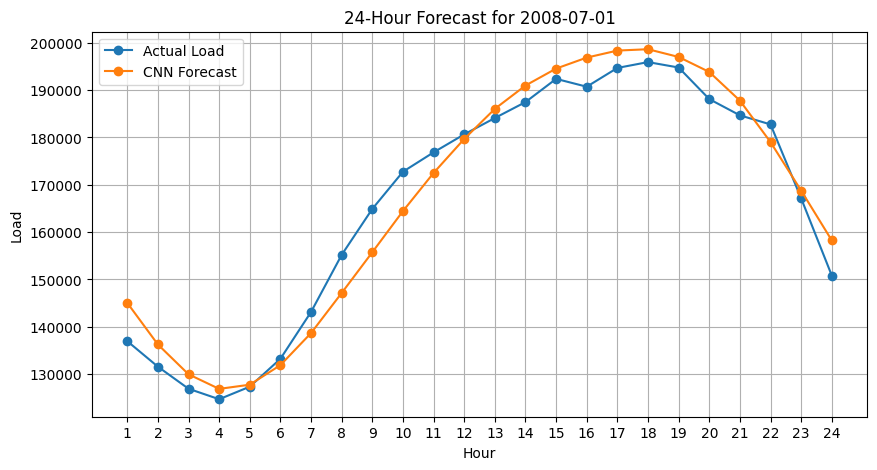

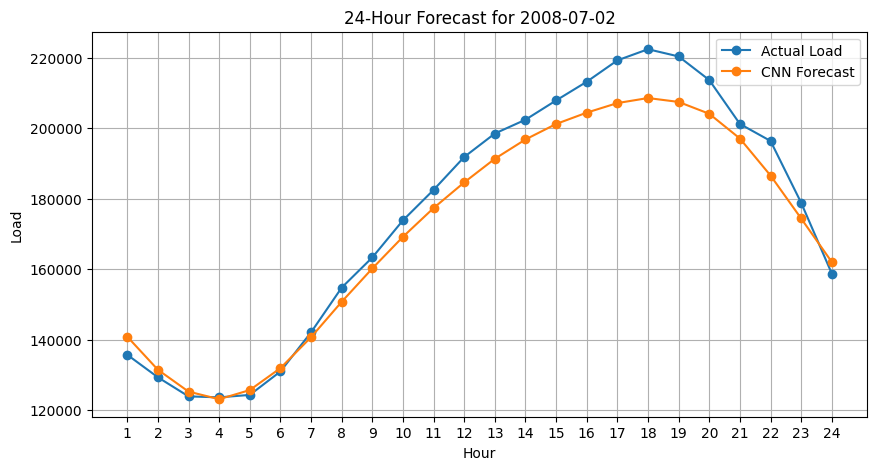

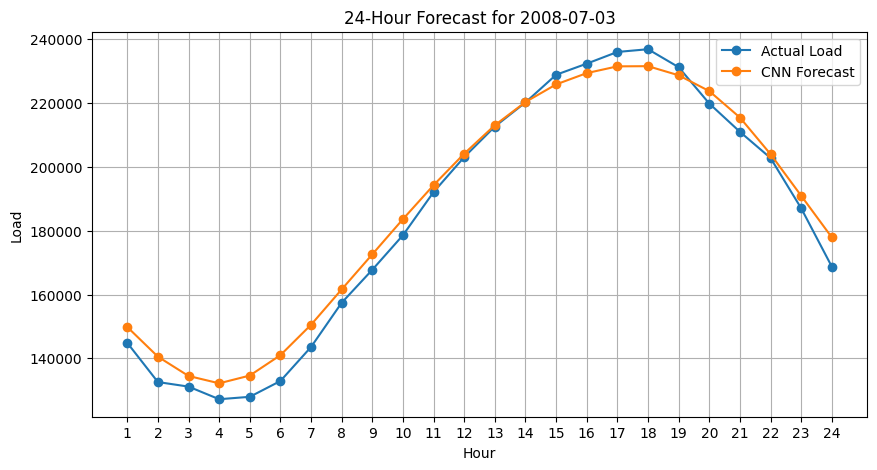

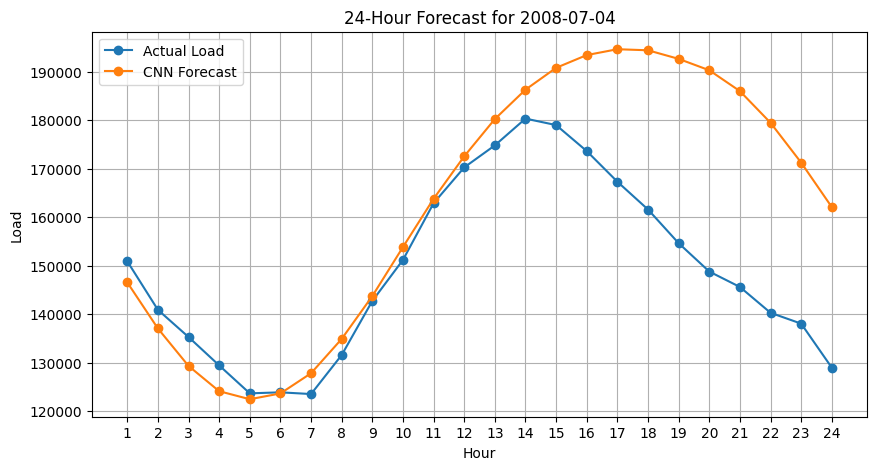

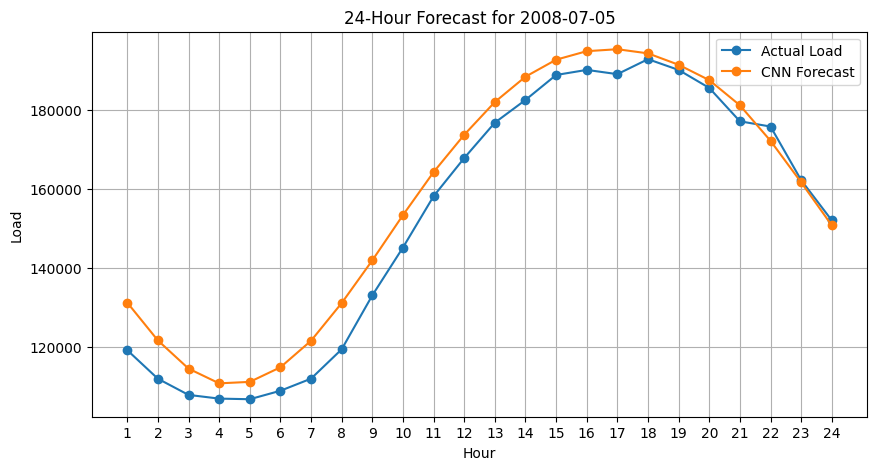

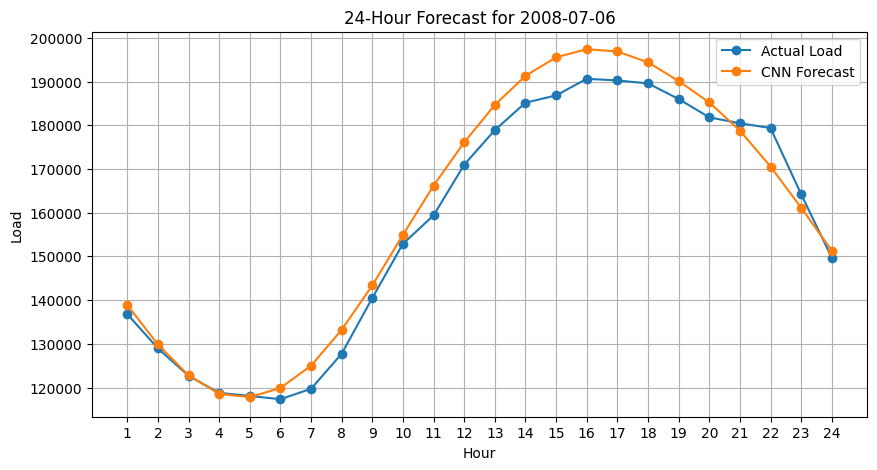

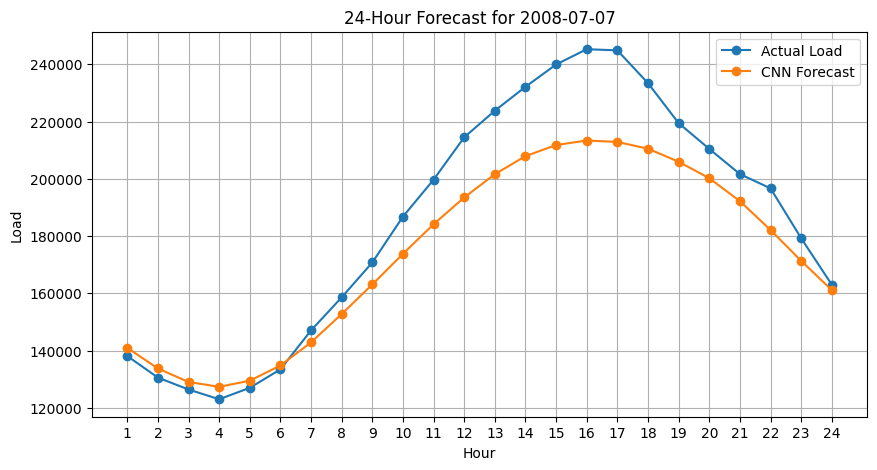

In [14]:
model.eval()

# Combine scaled data so each test day can use the previous 168 hours
all_scaled = pd.concat([train, val, test])

test_dates = pd.date_range('2008-07-01', '2008-07-07', freq='D')

cnn_forecasts = {}
actual_loads = {}

with torch.no_grad():
    for forecast_date in test_dates:
        forecast_start = forecast_date
        forecast_end = forecast_date + pd.Timedelta(hours=23)

        # Past 168 hours before the forecast day
        past_window = all_scaled.loc[:forecast_start - pd.Timedelta(hours=1)].tail(LOOKBACK)[feature_cols].copy()

        # Future known features for the forecast day
        future_window = all_scaled.loc[forecast_start:forecast_end][feature_cols].copy()

        # Future load is unknown, so set it to zero
        future_window['load'] = 0.0

        input_window = pd.concat([past_window, future_window], axis=0)

        X_test_day = input_window.values.astype(np.float32)
        X_test_day = np.transpose(X_test_day, (1, 0))
        X_test_day = torch.tensor(X_test_day).unsqueeze(0).to(device)

        pred_scaled = model(X_test_day).cpu().numpy().reshape(-1)

        # Convert prediction back to original load scale
        pred_original = load_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)

        # Actual load for that day, also converted back to original scale
        actual_scaled = all_scaled.loc[forecast_start:forecast_end]['load'].values
        actual_original = load_scaler.inverse_transform(actual_scaled.reshape(-1, 1)).reshape(-1)

        cnn_forecasts[forecast_date.date()] = pred_original
        actual_loads[forecast_date.date()] = actual_original

# -----------------------------
# Plot forecasts
# -----------------------------
for forecast_date in test_dates:
    date_key = forecast_date.date()
    hours = np.arange(1, 25)

    plt.figure(figsize=(10, 5))
    plt.plot(hours, actual_loads[date_key], marker='o', label='Actual Load')
    plt.plot(hours, cnn_forecasts[date_key], marker='o', label='CNN Forecast')

    plt.title(f'24-Hour Forecast for {date_key}')
    plt.xlabel('Hour')
    plt.ylabel('Load')
    plt.xticks(hours)
    plt.grid(True)
    plt.legend()
    plt.show()

# Step 7: Evaluation

Per-day RMSE and MAE for the CNN and the benchmark across the 7 test days (2008-07-01 .. 2008-07-07), then the mean across samples. The benchmark forecast is taken from `load_benchmark`.

In [15]:
# Build the benchmark forecast dictionary keyed by date
benchmark_forecasts = {}
for forecast_date in test_dates:
    day_slice = df_load_benchmark.loc[forecast_date:forecast_date + pd.Timedelta(hours=23)]
    benchmark_forecasts[forecast_date.date()] = day_slice['load'].values

# Scale sanity check: confirm benchmark and actual are in the same units (kW, ~10^5)
sample_date = list(actual_loads.keys())[0]
print('Scale check (kW):')
print(f'  Actual    day-1 mean = {actual_loads[sample_date].mean():,.0f}')
print(f'  CNN       day-1 mean = {cnn_forecasts[sample_date].mean():,.0f}')
print(f'  Benchmark day-1 mean = {benchmark_forecasts[sample_date].mean():,.0f}')

def rmse(pred, true):
    return float(np.sqrt(np.mean((pred - true) ** 2)))

def mae(pred, true):
    return float(np.mean(np.abs(pred - true)))

rows = []
for forecast_date in test_dates:
    date_key  = forecast_date.date()
    actual    = actual_loads[date_key]
    cnn_pred  = cnn_forecasts[date_key]
    bench     = benchmark_forecasts[date_key]
    rows.append({
        'date': str(date_key),
        'CNN_RMSE':       rmse(cnn_pred, actual),
        'Benchmark_RMSE': rmse(bench, actual),
        'CNN_MAE':        mae(cnn_pred, actual),
        'Benchmark_MAE':  mae(bench, actual),
    })

results_df = pd.DataFrame(rows)
mean_row = {
    'date': 'MEAN',
    'CNN_RMSE':       results_df['CNN_RMSE'].mean(),
    'Benchmark_RMSE': results_df['Benchmark_RMSE'].mean(),
    'CNN_MAE':        results_df['CNN_MAE'].mean(),
    'Benchmark_MAE':  results_df['Benchmark_MAE'].mean(),
}
results_df = pd.concat([results_df, pd.DataFrame([mean_row])], ignore_index=True)

print()
print(results_df.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))

cnn_mean_rmse   = mean_row['CNN_RMSE']
bench_mean_rmse = mean_row['Benchmark_RMSE']
cnn_mean_mae    = mean_row['CNN_MAE']
bench_mean_mae  = mean_row['Benchmark_MAE']

print(f"\nCNN beats benchmark on RMSE? {cnn_mean_rmse < bench_mean_rmse}  "
      f"(CNN {cnn_mean_rmse:,.2f} vs Benchmark {bench_mean_rmse:,.2f})")
print(f"CNN beats benchmark on MAE?  {cnn_mean_mae < bench_mean_mae}   "
      f"(CNN {cnn_mean_mae:,.2f} vs Benchmark {bench_mean_mae:,.2f})")


Scale check (kW):
  Actual    day-1 mean = 166,158
  CNN       day-1 mean = 166,921
  Benchmark day-1 mean = 194,205

      date  CNN_RMSE  Benchmark_RMSE   CNN_MAE  Benchmark_MAE
2008-07-01  4,827.93       30,313.97  4,127.78      28,047.00
2008-07-02  6,799.09       19,989.05  5,641.53      19,434.38
2008-07-03  4,849.14       11,470.91  4,244.99       9,853.29
2008-07-04 21,496.29       50,078.75 15,160.22      46,022.17
2008-07-05  6,385.94       27,485.84  5,552.66      24,262.50
2008-07-06  4,727.91       15,516.02  3,973.09      14,711.54
2008-07-07 15,946.18       12,378.89 12,621.89       9,509.96
      MEAN  9,290.35       23,890.49  7,331.74      21,691.55

CNN beats benchmark on RMSE? True  (CNN 9,290.35 vs Benchmark 23,890.49)
CNN beats benchmark on MAE?  True   (CNN 7,331.74 vs Benchmark 21,691.55)


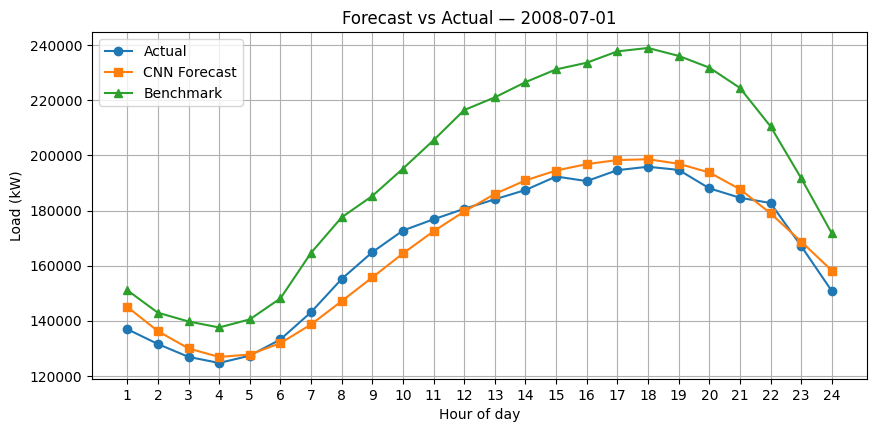

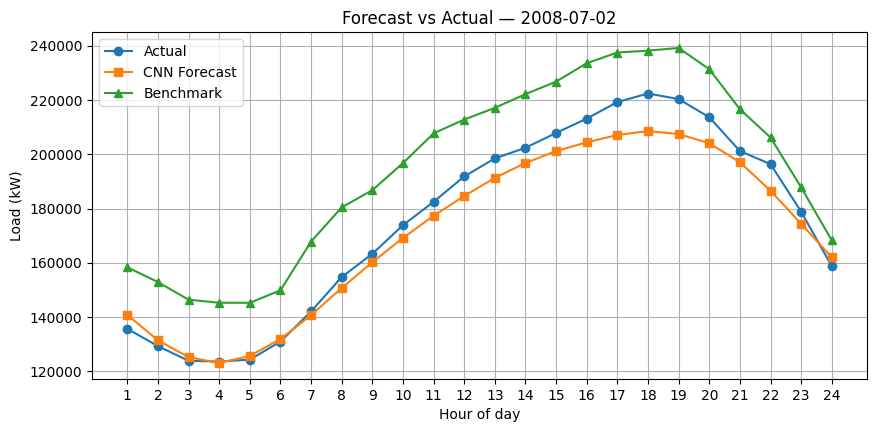

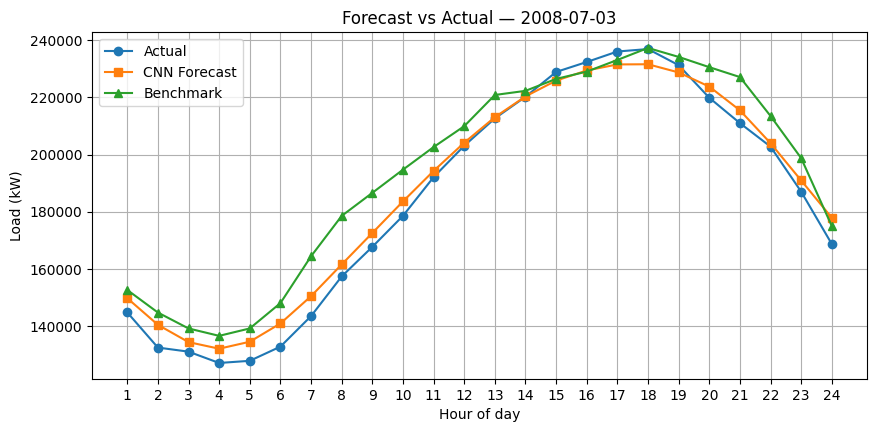

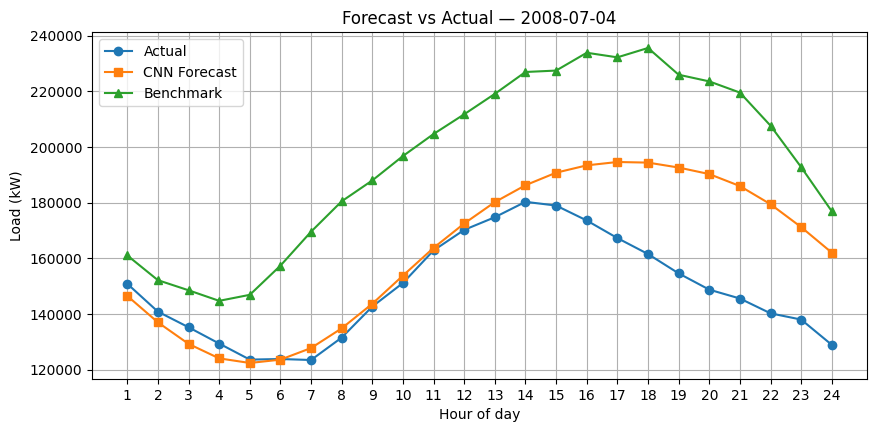

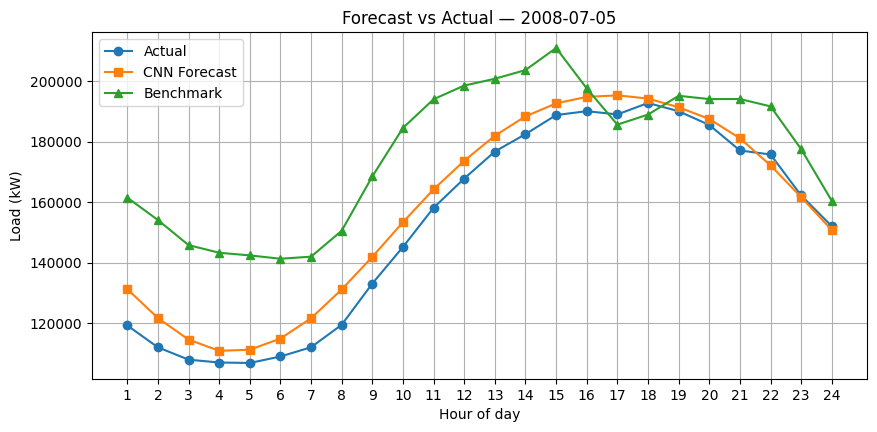

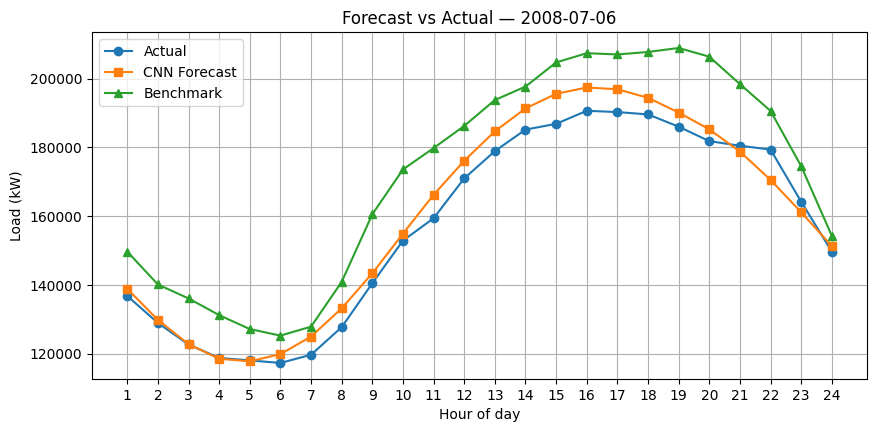

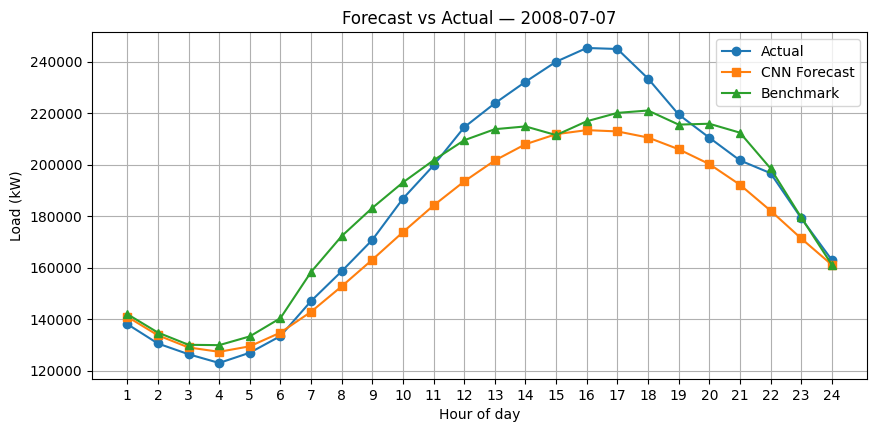

In [16]:
# Per-day overlay plot: actual vs CNN vs benchmark
for forecast_date in test_dates:
    date_key = forecast_date.date()
    hours = np.arange(1, 25)
    plt.figure(figsize=(10, 4.5))
    plt.plot(hours, actual_loads[date_key],       marker='o', label='Actual')
    plt.plot(hours, cnn_forecasts[date_key],      marker='s', label='CNN Forecast')
    plt.plot(hours, benchmark_forecasts[date_key], marker='^', label='Benchmark')
    plt.title(f'Forecast vs Actual — {date_key}')
    plt.xlabel('Hour of day'); plt.ylabel('Load (kW)')
    plt.xticks(hours); plt.grid(True); plt.legend()
    plt.show()


# AI Usage

AI tools were used throughout this project to support development, problem-solving and validation of the electricity forecasting pipeline.

ChatGPT was used to help:
- develop and refine parts of the Python and PyTorch implementation
- troubleshoot errors across data preprocessing, model development and evaluation
- explore and compare feature-engineering and modelling approaches
- review code, identify potential issues and suggest improvements
- iterate on solutions by refining prompts with relevant code, data context, technical constraints and expected behaviour

For example, during feature engineering, ChatGPT helped explore how periodic time variables could be represented using cyclical sine and cosine encoding. This approach was then implemented within the preprocessing pipeline and evaluated as part of the final model.

AI-assisted development was iterative. Code outputs, errors and evaluation results were fed back as context to refine prompts and improve subsequent solutions rather than treating the first response as final. Claude was also used as a secondary review tool to cross-check parts of the implementation and technical reasoning.

The resulting implementation was tested throughout development and ultimately evaluated using validation data, unseen test data and comparison against the provided forecasting benchmark.